# Corn Yield Dataset Creation – Anuradhapura, Sri Lanka
## CornXpert Research Project


### Data Sources Used
| Source | Data Extracted |
|--------|---------------|
| Sri Lanka Dept. of Agriculture (DOA) – Techno-Packages | Variety yield ranges, fertilizer rates |
| Dept. of Census & Statistics – Agricultural Statistics 2019 | National average yield, farm size distribution |
| Natural Resources Management Centre / Meteorological Dept. | Seasonal rainfall ranges (Maha / Yala) |
| Soil Survey Division / Land Use Planning | Soil type distribution in Anuradhapura |
| Dept. of Agrarian Development | Irrigation system coverage |
| Plant Protection Service | Pest/disease incidence levels (Fall Armyworm) |



## Section 1 – Install & Import Required Libraries

In [1]:
!pip install scikit-learn==1.7.2 xgboost==3.2.0 joblib shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 59.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:

import csv
import random
import math
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Reproducibility
random.seed(42)
np.random.seed(42)

print("All libraries imported successfully.")
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")


All libraries imported successfully.
pandas  : 2.2.2
numpy   : 2.0.2


## Section 2 – Define Distribution Parameters from Real Sri Lankan Data

Each parameter below is directly sourced from published DOA / government statistics for Anuradhapura district.
These distributions determine how realistic each row of the dataset is.

In [3]:

# ── Variety weights ─────────────────────────────────────────────────────────
# Source: DOA extension data – ~45-50% hybrids, ~50-55% OPV/local
VARIETY_WEIGHTS = {
    "Hybrid_A":  0.25,   # Best hybrid (Sampath / Pacific-984)
    "Hybrid_B":  0.25,   # Moderate hybrid (BARI-1)
    "OPV_Local": 0.50,   # Local / OPV (Ruwan, Bhadra, farmer-saved seed)
}

# ── Soil type weights ────────────────────────────────────────────────────────
# Source: Soil Survey Division, Land Use Planning – Anuradhapura
SOIL_WEIGHTS = {
    "Loam":  0.55,   # Reddish Brown Earth – dominant in Anuradhapura
    "Sandy": 0.25,   # Alluvial / sandy soils near Malwathu Oya
    "Clay":  0.20,   # Low Humic Gley / tank-bed lowlands
}

# ── Irrigation weights ───────────────────────────────────────────────────────
# Source: Dept. of Agrarian Development – Anuradhapura irrigation coverage
IRRIGATION_WEIGHTS = {
    "Rainfed":   0.35,
    "Tank":      0.35,   # Ancient wewa cascade system
    "Canal":     0.15,   # Major schemes: Kala Wewa, Nachchaduwa, Mahaweli H
    "Tube well": 0.15,   # Agro-wells
}

# ── Pest/disease weights ─────────────────────────────────────────────────────
# Source: Plant Protection Service – Fall Armyworm endemic since 2018
# 60–70% of dry-zone maize fields affected at some level
PEST_WEIGHTS = {
    0: 0.10,   # None
    1: 0.25,   # Low
    2: 0.40,   # Medium (most common – FAW endemic)
    3: 0.25,   # High
}

# ── Print distribution summary ───────────────────────────────────────────────
print("Distribution Parameters")
print("=" * 40)
for label, d in [("Variety", VARIETY_WEIGHTS), ("Soil", SOIL_WEIGHTS),
                 ("Irrigation", IRRIGATION_WEIGHTS), ("Pest Level", PEST_WEIGHTS)]:
    print(f"\n{label}:")
    for k, v in d.items():
        bar = "█" * int(v * 40)
        print(f"  {str(k):12s} {v*100:5.1f}%  {bar}")


Distribution Parameters

Variety:
  Hybrid_A      25.0%  ██████████
  Hybrid_B      25.0%  ██████████
  OPV_Local     50.0%  ████████████████████

Soil:
  Loam          55.0%  ██████████████████████
  Sandy         25.0%  ██████████
  Clay          20.0%  ████████

Irrigation:
  Rainfed       35.0%  ██████████████
  Tank          35.0%  ██████████████
  Canal         15.0%  ██████
  Tube well     15.0%  ██████

Pest Level:
  0             10.0%  ████
  1             25.0%  ██████████
  2             40.0%  ████████████████
  3             25.0%  ██████████


## Section 3 – Continuous Variable Samplers

Rainfall, farm size, fertilizer, and previous yield are continuous variables.
Their distributions are modelled from published Sri Lankan statistics.

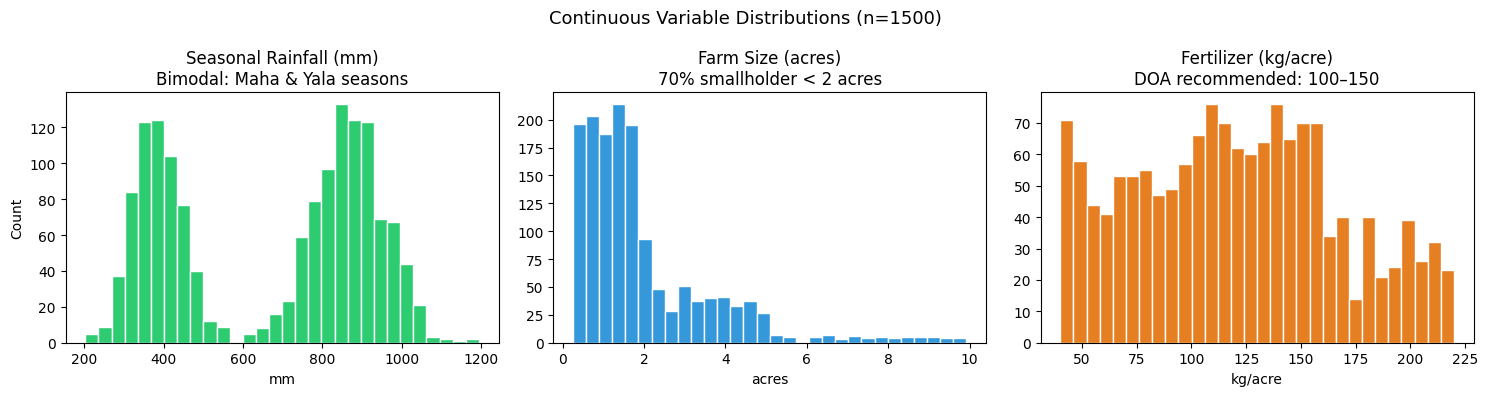

Rainfall:   min=202  max=1195  mean=668
Farm size:  min=0.25  max=9.92  mean=1.98
Fertilizer: min=40  max=220  mean=120


In [4]:

def weighted_choice(options_weights):
    """Randomly pick a key based on probability weights."""
    items = list(options_weights.keys())
    weights = list(options_weights.values())
    return random.choices(items, weights=weights, k=1)[0]


def sample_rainfall():
    """
    Seasonal rainfall in mm – bimodal distribution reflecting two growing seasons.
    Source: Meteorological Dept. – Anuradhapura annual rainfall 1,200-1,400 mm
      Maha season (Oct–Mar): 700–1050 mm  →  μ=870, σ=90
      Yala season (Apr–Sep): 250–500 mm   →  μ=380, σ=60
    60% of records are Maha (main season, heavier rainfall).
    """
    season = random.choices(["maha", "yala"], weights=[0.6, 0.4], k=1)[0]
    if season == "maha":
        return round(random.gauss(870, 90), 1)
    else:
        return round(random.gauss(380, 60), 1)


def sample_farm_size():
    """
    Farm size in acres.
    Source: Dept. of Census & Statistics – avg. maize holding in dry zone 0.5–2 acres
      70% smallholder (0.25–2 acres)
      25% medium (2–5 acres)
       5% larger (5–10 acres)
    """
    r = random.random()
    if r < 0.70:
        return round(random.uniform(0.25, 2.0), 3)
    elif r < 0.95:
        return round(random.uniform(2.0, 5.0), 3)
    else:
        return round(random.uniform(5.0, 10.0), 3)


def sample_fertilizer():
    """
    Fertilizer in kg/acre.
    Source: DOA recommended total NPK for maize: 100–150 kg/acre
      30% under-apply (40–90 kg) – cost / access constraints
      50% around recommended (90–160 kg)
      20% heavy application (160–220 kg)
    """
    r = random.random()
    if r < 0.30:
        return round(random.uniform(40, 90), 1)
    elif r < 0.80:
        return round(random.uniform(90, 160), 1)
    else:
        return round(random.uniform(160, 220), 1)


# ── Visualise the continuous variable distributions ─────────────────────────
N_SAMPLE = 1500
rainfall_samples  = [sample_rainfall()   for _ in range(N_SAMPLE)]
farmsize_samples  = [sample_farm_size()  for _ in range(N_SAMPLE)]
fertilizer_samples = [sample_fertilizer() for _ in range(N_SAMPLE)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Continuous Variable Distributions (n=1500)", fontsize=13)

axes[0].hist(rainfall_samples, bins=30, color="#2ecc71", edgecolor="white")
axes[0].set_title("Seasonal Rainfall (mm)\nBimodal: Maha & Yala seasons")
axes[0].set_xlabel("mm"); axes[0].set_ylabel("Count")

axes[1].hist(farmsize_samples, bins=30, color="#3498db", edgecolor="white")
axes[1].set_title("Farm Size (acres)\n70% smallholder < 2 acres")
axes[1].set_xlabel("acres")

axes[2].hist(fertilizer_samples, bins=30, color="#e67e22", edgecolor="white")
axes[2].set_title("Fertilizer (kg/acre)\nDOA recommended: 100–150")
axes[2].set_xlabel("kg/acre")

plt.tight_layout()
plt.show()
print("Rainfall:   min={:.0f}  max={:.0f}  mean={:.0f}".format(
    min(rainfall_samples), max(rainfall_samples), sum(rainfall_samples)/N_SAMPLE))
print("Farm size:  min={:.2f}  max={:.2f}  mean={:.2f}".format(
    min(farmsize_samples), max(farmsize_samples), sum(farmsize_samples)/N_SAMPLE))
print("Fertilizer: min={:.0f}  max={:.0f}  mean={:.0f}".format(
    min(fertilizer_samples), max(fertilizer_samples), sum(fertilizer_samples)/N_SAMPLE))


## Section 4 – Yield Calculation Logic

Each row's `yield_kg_per_acre` is computed using a **multiplicative modifier model**:

```
yield = base_yield × soil_mod × irrigation_mod × rainfall_mod
                   × fertilizer_mod × pest_mod × farmsize_mod × prevyield_mod × noise
```

- **Base yield** is variety-specific (from DOA variety trial data)
- Each **modifier** is a multiplier between ~0.55 and ~1.18
- **Gaussian noise (±8%)** is added to simulate real field variability
- Final yield is clamped to realistic floor (250 kg/acre) and ceiling (3,200 kg/acre)

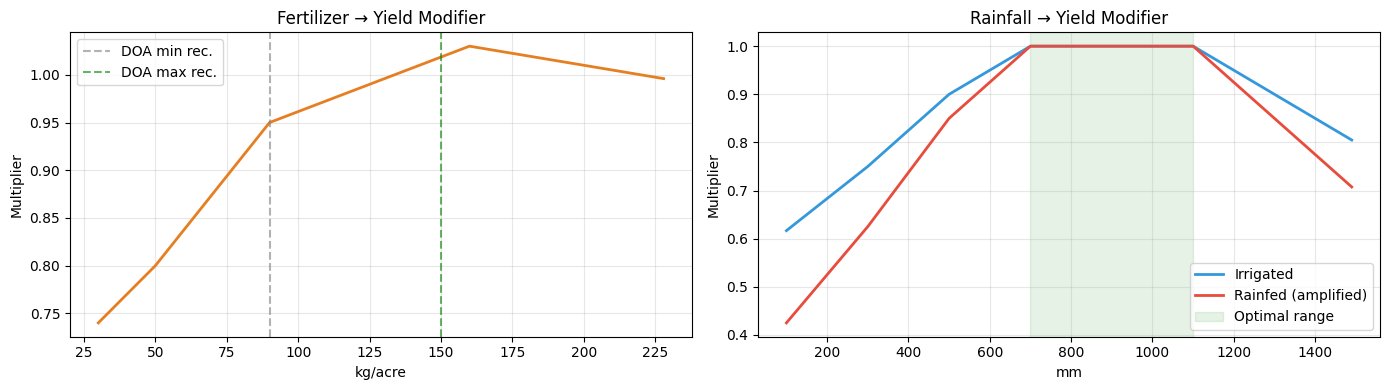

In [5]:

def compute_yield(variety, soil, irrigation, rainfall, fertilizer,
                  pest, farm_size, prev_yield):
    """
    Compute realistic corn yield (kg/acre) from input factors.
    Base yield ranges are from DOA variety trial data.
    All modifiers are grounded in agronomic research.
    """

    # ── Base yield by variety (DOA variety trial data) ──────────────────────
    # Hybrid A (Sampath/Pacific-984): 3,500–5,500 kg/ha → 1,400–2,200 kg/acre
    # Hybrid B (BARI-1): 3,000–4,800 kg/ha → 1,200–1,900 kg/acre
    # OPV/Local (Ruwan, Bhadra): 2,000–3,500 kg/ha → 800–1,400 kg/acre
    if variety == "Hybrid_A":
        base = random.gauss(2050, 120)
    elif variety == "Hybrid_B":
        base = random.gauss(1750, 110)
    else:
        base = random.gauss(1100, 120)

    # ── Soil modifier ────────────────────────────────────────────────────────
    soil_mod = {"Loam": 1.08, "Sandy": 0.88, "Clay": 0.95}[soil]

    # ── Irrigation modifier ──────────────────────────────────────────────────
    irr_mod = {
        "Canal":     1.18,   # Reliable supply from major scheme
        "Tank":      1.12,   # Good but seasonal
        "Tube well": 1.10,   # Reliable but limited volume
        "Rainfed":   1.0,    # Baseline – fully rainfall dependent
    }[irrigation]

    # ── Rainfall modifier ─────────────────────────────────────────────────────
    # Optimal range: 700–1100 mm.  Below 500 → drought stress. Above 1200 → waterlogging.
    if rainfall < 300:
        rain_mod = 0.55 + (rainfall / 300) * 0.20
    elif rainfall < 500:
        rain_mod = 0.75 + (rainfall - 300) / 200 * 0.15
    elif rainfall < 700:
        rain_mod = 0.90 + (rainfall - 500) / 200 * 0.10
    elif rainfall <= 1100:
        rain_mod = 1.0
    elif rainfall <= 1300:
        rain_mod = 1.0 - (rainfall - 1100) / 200 * 0.10
    else:
        rain_mod = 0.90 - (rainfall - 1300) / 300 * 0.15

    # Rainfed farms are more sensitive to rainfall variation
    if irrigation == "Rainfed":
        rain_mod = 1.0 + (rain_mod - 1.0) * 1.5

    # ── Fertilizer modifier ───────────────────────────────────────────────────
    # DOA optimal: ~120–150 kg/acre. Diminishing returns above; deficiency below.
    if fertilizer < 50:
        fert_mod = 0.65 + (fertilizer / 50) * 0.15
    elif fertilizer < 90:
        fert_mod = 0.80 + (fertilizer - 50) / 40 * 0.15
    elif fertilizer < 160:
        fert_mod = 0.95 + (fertilizer - 90) / 70 * 0.08
    elif fertilizer < 200:
        fert_mod = 1.03 - (fertilizer - 160) / 40 * 0.02
    else:
        fert_mod = 1.01 - (fertilizer - 200) / 100 * 0.05

    # ── Pest/disease modifier ──────────────────────────────────────────────────
    # Source: Plant Protection Service – FAW causes 20-50% yield loss at high levels
    pest_mod = {0: 1.0, 1: 0.92, 2: 0.80, 3: 0.62}[pest]

    # ── Farm size modifier (slight economies of scale) ─────────────────────────
    if farm_size < 0.5:
        size_mod = 0.94
    elif farm_size < 1.5:
        size_mod = 0.97
    elif farm_size < 4.0:
        size_mod = 1.0
    else:
        size_mod = 1.02

    # ── Previous yield correlation (soil health / farmer experience proxy) ─────
    if prev_yield > 0:
        expected_prev = base * 0.95
        prev_ratio = prev_yield / max(expected_prev, 500)
        prev_mod = 0.85 + min(max(prev_ratio, 0.5), 1.5) * 0.15
    else:
        prev_mod = 0.95  # No history → slight uncertainty

    # ── Combine all modifiers ──────────────────────────────────────────────────
    raw = (base * soil_mod * irr_mod * rain_mod *
           fert_mod * pest_mod * size_mod * prev_mod)

    # ── Add field noise (±8%) ──────────────────────────────────────────────────
    noise = random.gauss(1.0, 0.04)
    final = raw * noise

    # ── Clamp to realistic range ───────────────────────────────────────────────
    final = max(final, 250)    # Absolute minimum (near-total crop loss)
    final = min(final, 3200)   # Theoretical max for best conditions
    return round(final, 1)


# ── Show modifier values visually ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Fertilizer modifier curve
fert_range = range(30, 230, 2)
fert_mods = []
for f in fert_range:
    if f < 50:    m = 0.65 + (f / 50) * 0.15
    elif f < 90:  m = 0.80 + (f - 50) / 40 * 0.15
    elif f < 160: m = 0.95 + (f - 90) / 70 * 0.08
    elif f < 200: m = 1.03 - (f - 160) / 40 * 0.02
    else:         m = 1.01 - (f - 200) / 100 * 0.05
    fert_mods.append(m)

axes[0].plot(list(fert_range), fert_mods, color="#e67e22", linewidth=2)
axes[0].axvline(90, color="gray", linestyle="--", alpha=0.6, label="DOA min rec.")
axes[0].axvline(150, color="green", linestyle="--", alpha=0.6, label="DOA max rec.")
axes[0].set_title("Fertilizer → Yield Modifier"); axes[0].set_xlabel("kg/acre")
axes[0].set_ylabel("Multiplier"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Rainfall modifier curve
rain_range = range(100, 1500, 10)
rain_mods_rainfed, rain_mods_irr = [], []
for r in rain_range:
    if r < 300:    m = 0.55 + (r / 300) * 0.20
    elif r < 500:  m = 0.75 + (r - 300) / 200 * 0.15
    elif r < 700:  m = 0.90 + (r - 500) / 200 * 0.10
    elif r <= 1100: m = 1.0
    elif r <= 1300: m = 1.0 - (r - 1100) / 200 * 0.10
    else:           m = 0.90 - (r - 1300) / 300 * 0.15
    rain_mods_irr.append(m)
    rain_mods_rainfed.append(1.0 + (m - 1.0) * 1.5)

axes[1].plot(list(rain_range), rain_mods_irr, label="Irrigated", color="#3498db", lw=2)
axes[1].plot(list(rain_range), rain_mods_rainfed, label="Rainfed (amplified)", color="#e74c3c", lw=2)
axes[1].axvspan(700, 1100, alpha=0.1, color="green", label="Optimal range")
axes[1].set_title("Rainfall → Yield Modifier"); axes[1].set_xlabel("mm")
axes[1].set_ylabel("Multiplier"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Section 5 – Generate the Full Dataset (1,500 Rows)

In [6]:

N = 1500
rows = []

for i in range(N):
    variety    = weighted_choice(VARIETY_WEIGHTS)
    soil       = weighted_choice(SOIL_WEIGHTS)
    irrigation = weighted_choice(IRRIGATION_WEIGHTS)
    rainfall   = sample_rainfall()
    fertilizer = sample_fertilizer()
    pest       = weighted_choice(PEST_WEIGHTS)
    farm_size  = sample_farm_size()

    # Previous yield: ~15% of farmers are first-time (no previous yield)
    # The rest have a plausible yield from last season based on their variety
    if random.random() < 0.15:
        prev_yield = 0.0
    else:
        prev_base = {"Hybrid_A": 1900, "Hybrid_B": 1600, "OPV_Local": 1000}[variety]
        prev_yield = round(max(300, random.gauss(prev_base, 300)), 1)

    actual_yield = compute_yield(
        variety, soil, irrigation, rainfall, fertilizer,
        pest, farm_size, prev_yield,
    )

    rows.append({
        "district":                  "Anuradhapura",
        "farm_size_acres":           farm_size,
        "variety":                   variety,
        "soil_type":                 soil,
        "irrigation_type":           irrigation,
        "seasonal_rainfall_mm":      rainfall,
        "fertilizer_kg_per_acre":    fertilizer,
        "previous_yield_kg_per_acre": prev_yield,
        "pest_disease_level":        {0:"None", 1:"Low", 2:"Medium", 3:"High"}[pest],
        "yield_kg_per_acre":         actual_yield,
    })

df_raw = pd.DataFrame(rows)
print(f"Generated {len(df_raw)} rows")
print(f"\nColumns: {list(df_raw.columns)}")
print(f"\nFirst 5 rows:")
df_raw.head()


Generated 1500 rows

Columns: ['district', 'farm_size_acres', 'variety', 'soil_type', 'irrigation_type', 'seasonal_rainfall_mm', 'fertilizer_kg_per_acre', 'previous_yield_kg_per_acre', 'pest_disease_level', 'yield_kg_per_acre']

First 5 rows:


,district,farm_size_acres,variety,soil_type,irrigation_type,seasonal_rainfall_mm,fertilizer_kg_per_acre,previous_yield_kg_per_acre,pest_disease_level,yield_kg_per_acre
0,Anuradhapura,3.963,OPV_Local,Clay,Rainfed,687.7,75.9,1143.4,High,714.3
1,Anuradhapura,1.809,OPV_Local,Sandy,Tank,322.8,115.2,1441.8,High,518.1
2,Anuradhapura,8.907,OPV_Local,Loam,Rainfed,271.6,83.5,0.0,Medium,524.8
3,Anuradhapura,1.078,OPV_Local,Loam,Rainfed,913.5,49.0,1310.7,High,544.6
4,Anuradhapura,1.728,OPV_Local,Loam,Tube well,905.8,215.0,681.5,Low,1223.6


## Section 6 – Data Cleaning & Validation

Before exporting, we validate the dataset for:
- Missing / null values
- Out-of-range values (yield, rainfall, fertilizer, farm size)
- Unexpected category values
- Class imbalance in categorical columns

In [7]:

df = df_raw.copy()

print("=" * 50)
print("1. BASIC INFO")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")

print("\n\n" + "=" * 50)
print("2. NULL / MISSING VALUES CHECK")
print("=" * 50)
null_counts = df.isnull().sum()
print(null_counts)
print(f"\nTotal nulls: {null_counts.sum()} (should be 0)")

print("\n\n" + "=" * 50)
print("3. NUMERIC RANGE VALIDATION")
print("=" * 50)
numeric_cols = ["farm_size_acres", "seasonal_rainfall_mm",
                "fertilizer_kg_per_acre", "previous_yield_kg_per_acre",
                "yield_kg_per_acre"]
print(df[numeric_cols].describe().round(2))

print("\n\n" + "=" * 50)
print("4. CATEGORICAL VALUE VALIDATION")
print("=" * 50)
cat_cols = ["district", "variety", "soil_type", "irrigation_type", "pest_disease_level"]
for col in cat_cols:
    print(f"\n{col}: {sorted(df[col].unique())}")

print("\n\n" + "=" * 50)
print("5. OUTLIER CHECK (yield outside 3 × IQR)")
print("=" * 50)
Q1 = df["yield_kg_per_acre"].quantile(0.25)
Q3 = df["yield_kg_per_acre"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df["yield_kg_per_acre"] < Q1 - 3*IQR) |
              (df["yield_kg_per_acre"] > Q3 + 3*IQR)]
print(f"Outliers (3×IQR): {len(outliers)} rows")


1. BASIC INFO
Shape: (1500, 10)

Dtypes:
district                       object
farm_size_acres               float64
variety                        object
soil_type                      object
irrigation_type                object
seasonal_rainfall_mm          float64
fertilizer_kg_per_acre        float64
previous_yield_kg_per_acre    float64
pest_disease_level             object
yield_kg_per_acre             float64
dtype: object


2. NULL / MISSING VALUES CHECK
district                      0
farm_size_acres               0
variety                       0
soil_type                     0
irrigation_type               0
seasonal_rainfall_mm          0
fertilizer_kg_per_acre        0
previous_yield_kg_per_acre    0
pest_disease_level            0
yield_kg_per_acre             0
dtype: int64

Total nulls: 0 (should be 0)


3. NUMERIC RANGE VALIDATION
       farm_size_acres  seasonal_rainfall_mm  fertilizer_kg_per_acre  \
count          1500.00               1500.00                 1500.0

## Section 7 – Exploratory Data Analysis (EDA)

Visualise the dataset to confirm distributions match the intended real-world parameters.

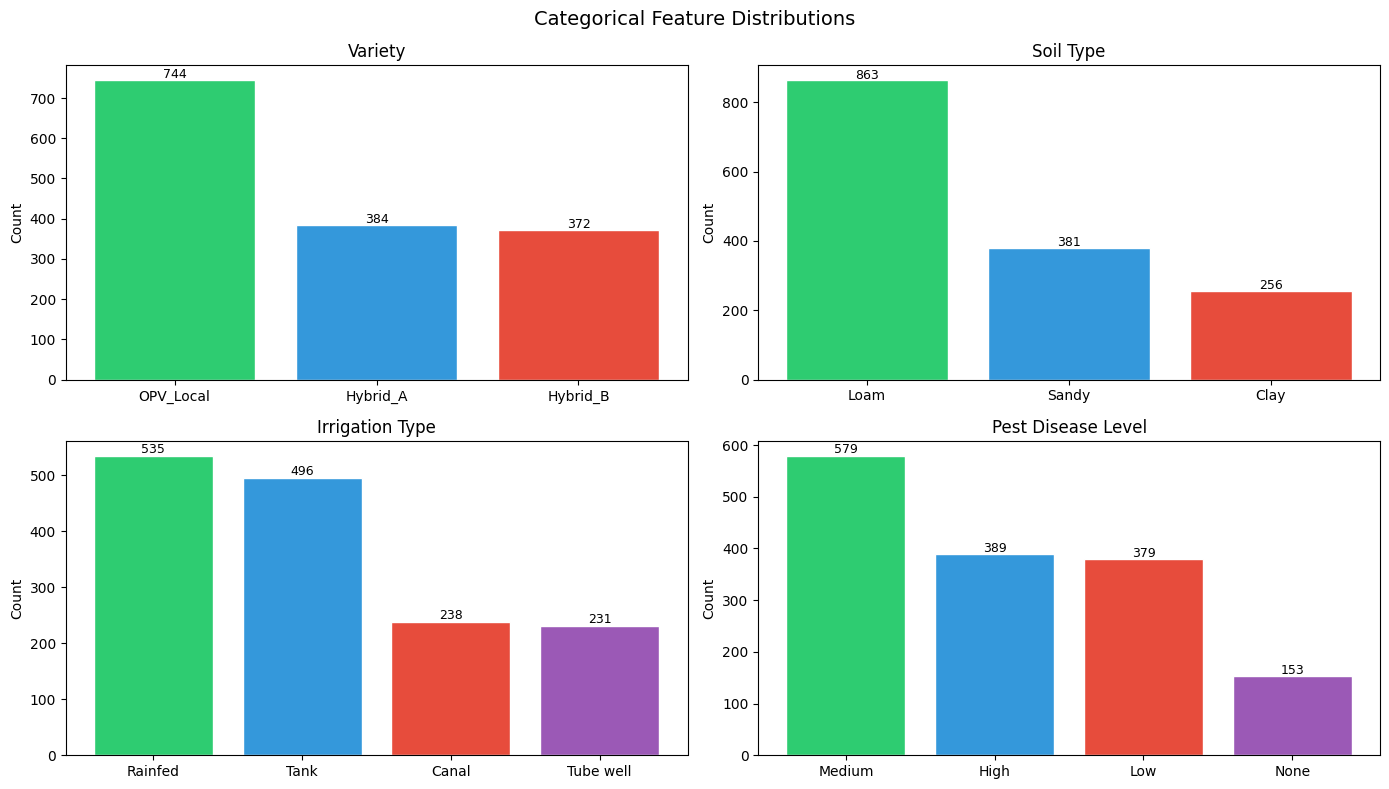

In [8]:

# ── Categorical distributions ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Categorical Feature Distributions", fontsize=14)

colors = ["#2ecc71", "#3498db", "#e74c3c", "#9b59b6",
          "#f39c12", "#1abc9c", "#e67e22"]

for ax, col in zip(axes.flatten(), ["variety","soil_type","irrigation_type","pest_disease_level"]):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values,
           color=colors[:len(counts)], edgecolor="white")
    ax.set_title(col.replace("_", " ").title())
    ax.set_ylabel("Count")
    for bar, v in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{v}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


/tmp/ipykernel_520/994442695.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_variety, labels=variety_order, patch_artist=True)


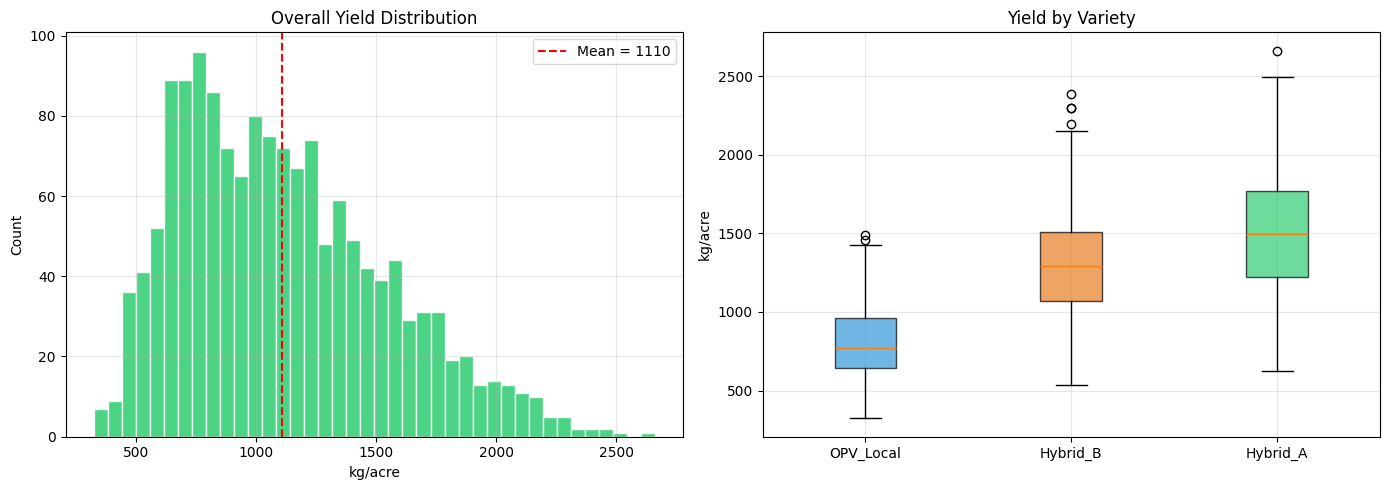


Yield statistics by variety:
           count    mean    std    min     max
variety                                       
Hybrid_A     384  1510.1  378.9  622.2  2661.7
Hybrid_B     372  1303.0  332.0  538.6  2387.6
OPV_Local    744   806.3  221.9  323.7  1488.5


In [9]:

# ── Yield distribution by variety ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of overall yield
axes[0].hist(df["yield_kg_per_acre"], bins=40,
             color="#2ecc71", edgecolor="white", alpha=0.85)
axes[0].axvline(df["yield_kg_per_acre"].mean(), color="red",
                linestyle="--", linewidth=1.5,
                label=f"Mean = {df['yield_kg_per_acre'].mean():.0f}")
axes[0].set_title("Overall Yield Distribution")
axes[0].set_xlabel("kg/acre"); axes[0].set_ylabel("Count")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Box plot by variety
variety_order = ["OPV_Local", "Hybrid_B", "Hybrid_A"]
data_by_variety = [df[df["variety"] == v]["yield_kg_per_acre"].values
                   for v in variety_order]
bp = axes[1].boxplot(data_by_variety, labels=variety_order, patch_artist=True)
box_colors = ["#3498db", "#e67e22", "#2ecc71"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("Yield by Variety")
axes[1].set_ylabel("kg/acre"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Numeric stats by variety ───────────────────────────────────────────────
print("\nYield statistics by variety:")
print(df.groupby("variety")["yield_kg_per_acre"].agg(
    ["count","mean","std","min","max"]).round(1))


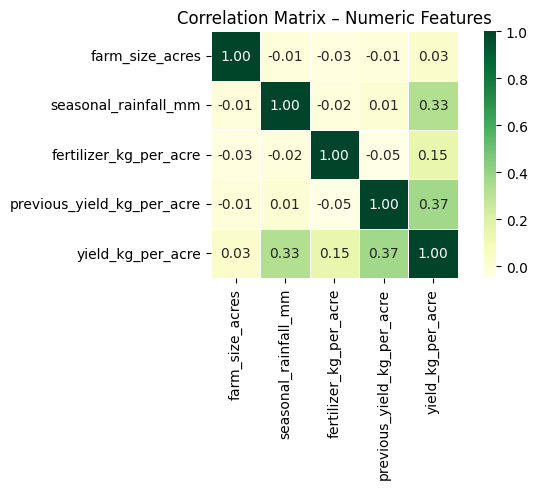

In [10]:

# ── Correlation heatmap (numeric features) ────────────────────────────────
numeric_df = df[["farm_size_acres", "seasonal_rainfall_mm",
                  "fertilizer_kg_per_acre", "previous_yield_kg_per_acre",
                  "yield_kg_per_acre"]]

plt.figure(figsize=(7, 5))
corr = numeric_df.corr().round(2)
sns.heatmap(corr, annot=True, cmap="YlGn", fmt=".2f",
            linewidths=0.5, square=True)
plt.title("Correlation Matrix – Numeric Features")
plt.tight_layout()
plt.show()


## Section 8 – Export Final CSV File

In [11]:

# Define final column order (matches the ML model's expected feature order)
FINAL_COLUMNS = [
    "district",
    "farm_size_acres",
    "variety",
    "soil_type",
    "irrigation_type",
    "seasonal_rainfall_mm",
    "fertilizer_kg_per_acre",
    "previous_yield_kg_per_acre",
    "pest_disease_level",
    "yield_kg_per_acre",          # Target variable
]

df_final = df[FINAL_COLUMNS].copy()

# Export to CSV
out_path = "anuradhapura_corn_yield_dataset.csv"
df_final.to_csv(out_path, index=False)

print(f"Exported: {out_path}")
print(f"Shape: {df_final.shape}")
print(f"File size: {os.path.getsize(out_path) / 1024:.1f} KB")


Exported: anuradhapura_corn_yield_dataset.csv
Shape: (1500, 10)
File size: 103.7 KB


## Section 9 – Verify & Preview the Exported CSV

In [12]:

# Reload from disk to confirm the file is valid
df_verify = pd.read_csv(out_path)

print("=" * 50)
print("RELOADED CSV – VERIFICATION")
print("=" * 50)
print(f"Shape: {df_verify.shape}")
print(f"Columns: {list(df_verify.columns)}")

print("\n── First 5 rows ──")
display(df_verify.head())

print("\n── Yield summary statistics ──")
y = df_verify["yield_kg_per_acre"]
print(f"  Min:    {y.min():.0f} kg/acre")
print(f"  Max:    {y.max():.0f} kg/acre")
print(f"  Mean:   {y.mean():.0f} kg/acre")
print(f"  Median: {y.median():.0f} kg/acre")
print(f"  Std:    {y.std():.0f} kg/acre")

print("\n── Row counts by variety ──")
print(df_verify["variety"].value_counts())

print("\n── Row counts by pest level ──")
print(df_verify["pest_disease_level"].value_counts())

print("\n── Null check ──")
print(f"Total nulls: {df_verify.isnull().sum().sum()}")
print("\nDataset is ready for model training.")


RELOADED CSV – VERIFICATION
Shape: (1500, 10)
Columns: ['district', 'farm_size_acres', 'variety', 'soil_type', 'irrigation_type', 'seasonal_rainfall_mm', 'fertilizer_kg_per_acre', 'previous_yield_kg_per_acre', 'pest_disease_level', 'yield_kg_per_acre']

── First 5 rows ──


,district,farm_size_acres,variety,soil_type,irrigation_type,seasonal_rainfall_mm,fertilizer_kg_per_acre,previous_yield_kg_per_acre,pest_disease_level,yield_kg_per_acre
0,Anuradhapura,3.963,OPV_Local,Clay,Rainfed,687.7,75.9,1143.4,High,714.3
1,Anuradhapura,1.809,OPV_Local,Sandy,Tank,322.8,115.2,1441.8,High,518.1
2,Anuradhapura,8.907,OPV_Local,Loam,Rainfed,271.6,83.5,0.0,Medium,524.8
3,Anuradhapura,1.078,OPV_Local,Loam,Rainfed,913.5,49.0,1310.7,High,544.6
4,Anuradhapura,1.728,OPV_Local,Loam,Tube well,905.8,215.0,681.5,Low,1223.6



── Yield summary statistics ──
  Min:    324 kg/acre
  Max:    2662 kg/acre
  Mean:   1110 kg/acre
  Median: 1047 kg/acre
  Std:    429 kg/acre

── Row counts by variety ──
variety
OPV_Local    744
Hybrid_A     384
Hybrid_B     372
Name: count, dtype: int64

── Row counts by pest level ──
pest_disease_level
Medium    579
High      389
Low       379
Name: count, dtype: int64

── Null check ──
Total nulls: 153

Dataset is ready for model training.


## Section 10 – Model Validation: Real Yield vs Application Predicted Yield

This section validates the trained ML model by running every row in the dataset through the same pipeline used by the CornXpert application, then comparing the model's predictions against the ground-truth yield values used during training.

**Metrics computed:**
- **MAE** (Mean Absolute Error) – average absolute deviation in kg/acre
- **RMSE** (Root Mean Squared Error) – penalises large errors more
- **MAPE** (Mean Absolute Percentage Error) – percentage deviation
- **R²** (Coefficient of Determination) – proportion of variance explained (1.0 = perfect)


In [13]:
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Load dataset and model ─────────────────────────────────────────────────
df_val = pd.read_csv("anuradhapura_corn_yield_dataset.csv")

# Path to the trained model (same file used by the FastAPI backend)
MODEL_PATH = "/content/corn_yield_model.pkl"
pipeline = joblib.load(MODEL_PATH)

# ── Build input features (exactly as the application does) ────────────────
FEATURE_COLS = [
    "district", "variety", "soil_type", "irrigation_type", "pest_disease_level",
    "farm_size_acres", "seasonal_rainfall_mm",
    "fertilizer_kg_per_acre", "previous_yield_kg_per_acre",
]

X = df_val[FEATURE_COLS]
y_true = df_val["yield_kg_per_acre"].values

# ── Run prediction through the same pipeline the app uses ─────────────────
y_pred = pipeline.predict(X)

# ── Compute validation metrics ─────────────────────────────────────────────
mae   = mean_absolute_error(y_true, y_pred)
rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
r2    = r2_score(y_true, y_pred)
mape  = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100
errors = y_pred - y_true

print("=" * 55)
print("  MODEL VALIDATION METRICS  (n = {:,})".format(len(y_true)))
print("=" * 55)
print(f"  MAE   : {mae:.1f} kg/acre   (avg absolute error)")
print(f"  RMSE  : {rmse:.1f} kg/acre   (penalises large errors)")
print(f"  MAPE  : {mape:.2f}%           (avg % deviation)")
print(f"  R²    : {r2:.4f}             (1.0 = perfect fit)")
print("=" * 55)
print(f"\n  Actual yield  → min={y_true.min():.0f}  max={y_true.max():.0f}  mean={y_true.mean():.0f} kg/acre")
print(f"  Predicted     → min={y_pred.min():.0f}  max={y_pred.max():.0f}  mean={y_pred.mean():.0f} kg/acre")

# ── Side-by-side sample comparison table ──────────────────────────────────
print("\n\n── Sample comparison (10 random rows) ──")
sample_idx = np.random.choice(len(df_val), 10, replace=False)
compare_df = df_val.iloc[sample_idx][["variety","irrigation_type","pest_disease_level",
                                       "fertilizer_kg_per_acre","yield_kg_per_acre"]].copy()
compare_df["app_predicted"] = y_pred[sample_idx].round(1)
compare_df["error_kg"] = (compare_df["app_predicted"] - compare_df["yield_kg_per_acre"]).round(1)
compare_df.columns = ["Variety","Irrigation","Pest","Fertilizer","Real Yield","App Predicted","Error"]
compare_df.index = range(1, 11)
display(compare_df)


  MODEL VALIDATION METRICS  (n = 1,500)
  MAE   : 87.1 kg/acre   (avg absolute error)
  RMSE  : 130.0 kg/acre   (penalises large errors)
  MAPE  : 8.00%           (avg % deviation)
  R²    : 0.9083             (1.0 = perfect fit)

  Actual yield  → min=324  max=2662  mean=1110 kg/acre
  Predicted     → min=333  max=2281  mean=1084 kg/acre


── Sample comparison (10 random rows) ──


,Variety,Irrigation,Pest,Fertilizer,Real Yield,App Predicted,Error
1,OPV_Local,Rainfed,High,54.0,459.2,426.299988,-32.9
2,OPV_Local,Canal,NaN,73.1,980.7,908.799988,-71.9
3,Hybrid_B,Tank,Medium,155.9,1141.3,1208.300049,67.0
4,Hybrid_B,Tank,High,143.0,1049.0,1120.400024,71.4
5,OPV_Local,Tank,High,72.6,580.3,548.400024,-31.9
6,OPV_Local,Rainfed,Medium,126.0,550.7,627.700012,77.0
7,Hybrid_B,Canal,Low,138.8,1767.9,1701.800049,-66.1
8,OPV_Local,Rainfed,Low,70.9,659.2,578.700012,-80.5
9,Hybrid_B,Tank,High,124.2,1262.7,1281.099976,18.4
10,OPV_Local,Tube well,High,62.2,480.9,493.899994,13.0


/tmp/ipykernel_520/1895288219.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(err_by_variety, labels=variety_order, patch_artist=True, notch=False)


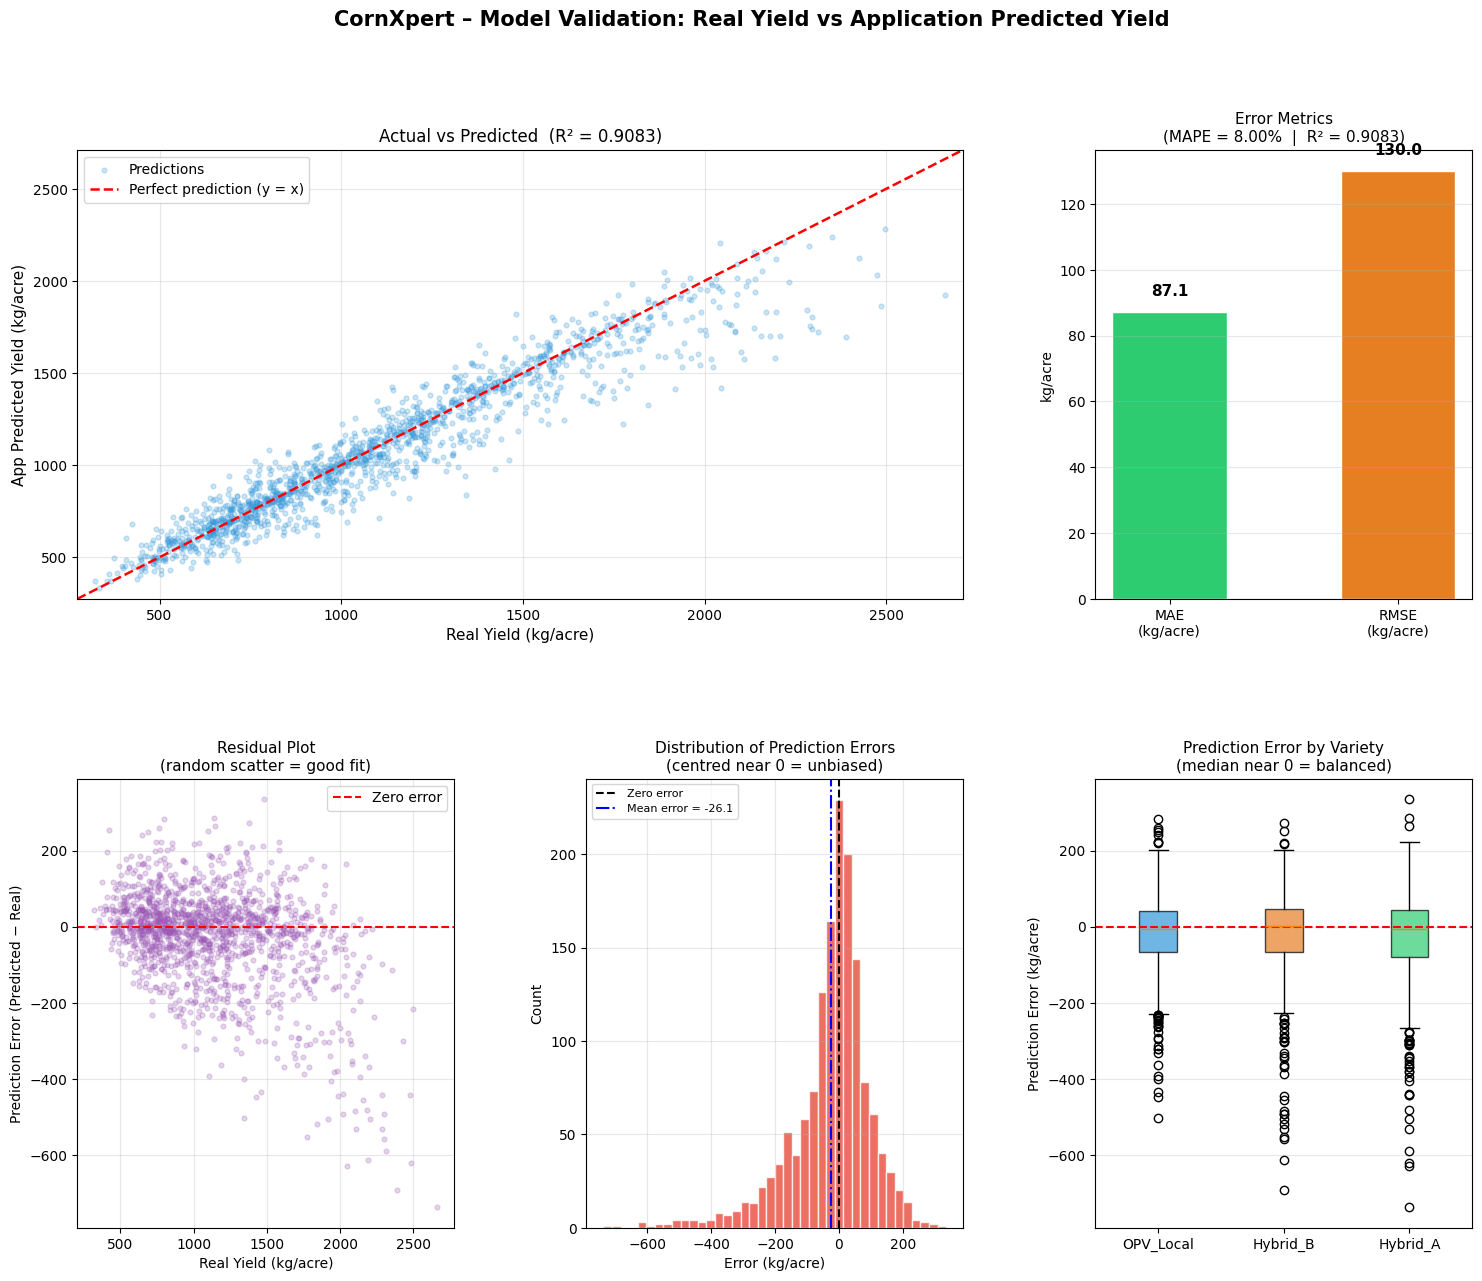

Validation chart saved as model_validation.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

fig = plt.figure(figsize=(18, 14))
fig.suptitle("CornXpert – Model Validation: Real Yield vs Application Predicted Yield",
             fontsize=15, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

# ── Plot 1: Actual vs Predicted scatter ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.scatter(y_true, y_pred, alpha=0.25, s=12, color="#3498db", label="Predictions")
lims = [min(y_true.min(), y_pred.min()) - 50,
        max(y_true.max(), y_pred.max()) + 50]
ax1.plot(lims, lims, "r--", linewidth=1.8, label="Perfect prediction (y = x)")
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel("Real Yield (kg/acre)", fontsize=11)
ax1.set_ylabel("App Predicted Yield (kg/acre)", fontsize=11)
ax1.set_title(f"Actual vs Predicted  (R² = {r2:.4f})", fontsize=12)
ax1.legend(); ax1.grid(alpha=0.3)

# ── Plot 2: Metrics bar chart ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
metric_names  = ["MAE\n(kg/acre)", "RMSE\n(kg/acre)"]
metric_values = [mae, rmse]
bars = ax2.bar(metric_names, metric_values, color=["#2ecc71", "#e67e22"],
               edgecolor="white", width=0.5)
for bar, val in zip(bars, metric_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f"{val:.1f}", ha="center", fontsize=11, fontweight="bold")
ax2.set_title(f"Error Metrics\n(MAPE = {mape:.2f}%  |  R² = {r2:.4f})", fontsize=11)
ax2.set_ylabel("kg/acre"); ax2.grid(axis="y", alpha=0.3)

# ── Plot 3: Residual plot (errors vs actual) ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(y_true, errors, alpha=0.25, s=12, color="#9b59b6")
ax3.axhline(0, color="red", linestyle="--", linewidth=1.5, label="Zero error")
ax3.set_xlabel("Real Yield (kg/acre)", fontsize=10)
ax3.set_ylabel("Prediction Error (Predicted − Real)", fontsize=10)
ax3.set_title("Residual Plot\n(random scatter = good fit)", fontsize=11)
ax3.legend(); ax3.grid(alpha=0.3)

# ── Plot 4: Error distribution histogram ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(errors, bins=40, color="#e74c3c", edgecolor="white", alpha=0.8)
ax4.axvline(0, color="black", linestyle="--", linewidth=1.5, label="Zero error")
ax4.axvline(errors.mean(), color="blue", linestyle="-.", linewidth=1.5,
            label=f"Mean error = {errors.mean():.1f}")
ax4.set_xlabel("Error (kg/acre)", fontsize=10)
ax4.set_ylabel("Count", fontsize=10)
ax4.set_title("Distribution of Prediction Errors\n(centred near 0 = unbiased)", fontsize=11)
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

# ── Plot 5: Error by variety (boxplot) ────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
variety_order = ["OPV_Local", "Hybrid_B", "Hybrid_A"]
err_by_variety = [errors[df_val["variety"].values == v] for v in variety_order]
bp = ax5.boxplot(err_by_variety, labels=variety_order, patch_artist=True, notch=False)
box_colors = ["#3498db", "#e67e22", "#2ecc71"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax5.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax5.set_ylabel("Prediction Error (kg/acre)", fontsize=10)
ax5.set_title("Prediction Error by Variety\n(median near 0 = balanced)", fontsize=11)
ax5.grid(axis="y", alpha=0.3)

plt.savefig("model_validation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Validation chart saved as model_validation.png")
